<center><b><font size="5">CLAS 2018 simple NN study</font></b></center>

# Intro

In [1]:
import gepard as g
print('Gepard version = {}'.format(g.__version__))

Gepard version = 0.9.10


In [2]:
# This just gets my current git revision hash, in case version number above is not reliable.
# You should comment this cell out if your Gepard installation is not git cloned from github repository.
import os
import subprocess
branch = subprocess.check_output(['git', '-C', os.path.dirname(g.__file__),
                                  'branch', '--show-current']).decode('ascii').strip()
revhash = subprocess.check_output(['git', '-C', os.path.dirname(g.__file__),
                                   'rev-parse', 'HEAD']).decode('ascii').strip()
print('Current git branch is "{}" and revision hash is {}'.format(branch, revhash))

Current git branch is "dev_Mel" and revision hash is dd5e2aceae4d24c8f1365249b8d77a273a66969e


In [3]:
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd 

In [4]:
import mydatafiles

In [5]:
mydset = g.data.loaddata(mydatafiles)

In [6]:
def plotpts(bin1, bin2=None, replica=None):
    """Plot points in bin with errorbars."""
    fig, ax = plt.subplots(1,1, figsize=[4,4])
    ax.errorbar(bin1.phi.values, bin1.val.values, bin1.err.values, color='blue', linestyle='None',
               capsize=3)
    if isinstance(bin2, pd.DataFrame):
        ax.errorbar(bin2.phi.values, bin2.val.values, bin2.err.values, color='red', linestyle='None',
                   capsize=2)
    if isinstance(replica, np.ndarray):
        ax.plot(bin1.phi.values, replica, marker='o', color='red', linestyle='None')
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlim(-np.pi, np.pi)
    fig.savefig('fig')

In [7]:
def plotbin(bin, th):
    """Plot points in bin with errorbars w.r.t. KM15."""
    fig, ax = plt.subplots(1,1, figsize=[4,4])
    bin1 = binXUU_df[bin]
    preds = []
    for pt in binXUU_pt[bin]:
        preds.append(th.predict(pt))
    preds = np.array(preds)
    ax.errorbar(bin1.phi.values, bin1.val.values, bin1.err.values, color='blue', linestyle='None',
               capsize=3)
    ax.plot(bin1.phi.values, preds, 'r-')
    # x.set_ylim(-0.5, 0.5)
    # ax.set_xlim(-np.pi, np.pi)
    fig.savefig('fig')

In [8]:
# New data from 2018, Melany's FT
g.describe_data(mydset[160]+mydset[161]+mydset[162])

npt x obs     collab  FTn    id  ref.        
----------------------------------------------
340 x XUU     CLAS    0.0    161 arxiv.org/pdf/1810.02110
339 x XUU     CLAS    1.0    161 arxiv.org/pdf/1810.02110
6016 x XUU     CLAS    N/A    160 arxiv.org/pdf/1810.02110
180 x XUUw    CLAS    0.0    162 arxiv.org/pdf/1810.02110
181 x XUUw    CLAS    1.0    162 arxiv.org/pdf/1810.02110
----------------------------------------------
TOTAL = 7056


In [9]:
# KK FTs  DO NOT USE SECOND HALF OF THESE DATASETS !!
g.describe_data(mydset[163])

npt x obs     collab  FTn    id  ref.        
----------------------------------------------
350 x XUU     CLAS    -1.0   163 arxiv.org/pdf/1810.02110
350 x XUU     CLAS    0.0    163 arxiv.org/pdf/1810.02110
350 x XUU     CLAS    1.0    163 arxiv.org/pdf/1810.02110
----------------------------------------------
TOTAL = 1050


## Binning

In [10]:
dfXUU = mydset[160].df()[['Q2', 'xB', 'tm', 'in1energy', 'phi', 'val', 'err', 'errstat', 'errsyst']]

In [11]:
# Detect bin breaks based on increasing phi jumps
phi_diff = dfXUU['phi'].diff().fillna(0)
bin_starts = [0] + list(phi_diff[phi_diff > 2.5].index) + [len(dfXUU)]

# Initialize bin dictionary and list for bin centers
binXUU_df = {}
binXUU_pt = {}
bin_centers = []

# Loop over bins
for k in range(len(bin_starts) - 1):
    start = bin_starts[k]
    end = bin_starts[k + 1]
    df_bin = dfXUU.iloc[start:end].copy().reset_index(drop=True)
    
    
    # Compute central values
    Q2_mean = df_bin['Q2'].mean()
    xB_mean = df_bin['xB'].mean()
    tm_mean = df_bin['tm'].mean()
    
    # Add central values to each row of the bin
    df_bin['Q2_center'] = Q2_mean
    df_bin['xB_center'] = xB_mean
    df_bin['tm_center'] = tm_mean
    
    # Save
    binXUU_df[k] = df_bin
    binXUU_pt[k] = mydset[160][start:end]
    bin_centers.append({'Q2': Q2_mean, 'xB': xB_mean, 'tm': tm_mean})

# Create bins dataframe from collected central values
bins = pd.DataFrame(bin_centers)
print('Number of all bins = {}'.format(len(bins)))

Number of all bins = 350


Note that only first 175 bins are XUU, rest are accidentaly left in the datafile ID=160.

## NNet classes

In [12]:
class NN2(g.model.NeuralModel, g.eff.KellyEFF, g.dvcs.BM10tw2):
    """NNet class with 2-input architecture (xB-t)."""

    def build_net(self):
            '''Overriding the default architecture and optimizer'''
            nn_model = torch.nn.Sequential(
                    torch.nn.Linear(2, 23),
                    torch.nn.ReLU(),
                    torch.nn.Linear(23, 37),
                    torch.nn.ReLU(),
                    torch.nn.Linear(37, 19),
                    torch.nn.ReLU(),
                    torch.nn.Linear(19, len(self.output_layer))
                )
            optimizer = torch.optim.Rprop(nn_model.parameters(), lr=0.01)
            return nn_model, optimizer

# Phi-dependent NN fitting  (xB-t NN inputs)

In [14]:
# some random bins, takeQ2 just every third point for fast intial study
fitsets = [binXUU_pt[40][::3]+binXUU_pt[51][::3]+binXUU_pt[62][::3],
          binXUU_pt[70][::3]+binXUU_pt[82][::3]+binXUU_pt[91][::3],
          binXUU_pt[110][::3]+binXUU_pt[121][::3]+binXUU_pt[132][::3]]

In [15]:
th = NN2(output_layer=['ImH', 'ReH', 'ReHt'], q2in=False, xpow=0)
f = g.fitter.NeuralFitter(fitsets, th, nnets=3, batchlen=5, regularization='L2', lx_lambda=0.002)

In [16]:
f.fit()


Epoch   5: train error = 5.0935 test error = 5.1411 -
Epoch  10: train error = 3.8863 test error = 5.8284 +
Epoch  15: train error = 3.1876 test error = 14.9405 +
Epoch  20: train error = 2.9673 test error = 9.2144 +
Epoch  25: train error = 2.8463 test error = 8.4329 +
Epoch  30: train error = 2.8075 test error = 8.4099 +
No improvement for 5 batches. Stopping early.
Net 0 --> test_err = 5.141109466552734

Epoch   5: train error = 4.4771 test error = 3.2744 -
Epoch  10: train error = 3.5011 test error = 2.3978 -
Epoch  15: train error = 3.1614 test error = 2.5514 +
Epoch  20: train error = 3.0046 test error = 2.5873 +
Epoch  25: train error = 2.9326 test error = 2.3766 -
Epoch  30: train error = 2.8905 test error = 2.2580 -
Epoch  35: train error = 2.8392 test error = 2.2615 +
Epoch  40: train error = 2.8051 test error = 2.1400 -
Epoch  45: train error = 2.7936 test error = 2.0833 -
Epoch  50: train error = 2.7833 test error = 2.0267 -
Epoch  55: train error = 2.7696 test error = 2.0

In [17]:
for dset in fitsets:
    print(th.chisq(dset))

(np.float64(7.583649608538296), 16, np.float64(0.9603063716966468))
(np.float64(77.62677163279243), 22, np.float64(3.964778194642804e-08))
(np.float64(33.02529181919308), 18, np.float64(0.016573159805889914))


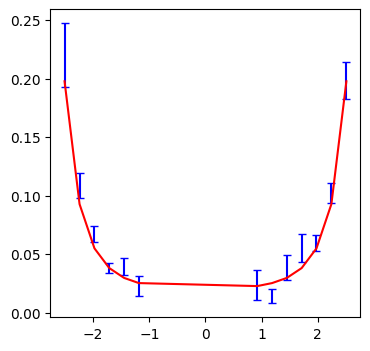

In [18]:
plotbin(51, th)

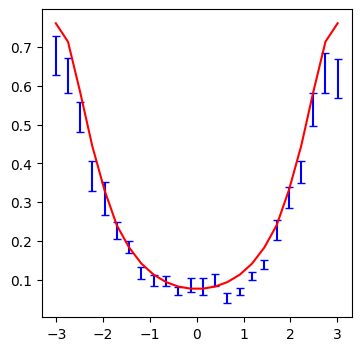

In [19]:
plotbin(91, th)

# Harmonic (unweighted) NN fitting (xB-t NN inputs)

In [20]:
# some random subset of points
fitsets_harm_proto = [mydset[163][40:70:2], mydset[163][71:101:2], mydset[163][102:132:2]]

In [21]:
# Pruning datasets
fitsets_harm = []
for dset in fitsets_harm_proto:
    newset = []
    for pt in dset:
        if abs(pt.t) < pt.Q2/4:
            if abs(pt.err) < abs(pt.val)/3:
                newset.append(pt)
    newset = g.DataSet(newset)
    fitsets_harm.append(newset)

In [22]:
fitsets_harm.append(mydset[163][96:103])

In [23]:
th_harm = NN2(output_layer=['ImH', 'ReH', 'ReHt'], q2in=False, xpow=0)
fh = g.fitter.NeuralFitter(fitsets_harm, th_harm, nnets=3, batchlen=3, regularization='L2', lx_lambda=0.002)

In [24]:
fh.fit()


Epoch   3: train error = 18.0265 test error = 24.0809 -
Epoch   6: train error = 17.6040 test error = 23.0580 -
Epoch   9: train error = 15.9223 test error = 22.4427 -
Epoch  12: train error = 15.2379 test error = 23.9278 +
Epoch  15: train error = 15.0319 test error = 25.3146 +
Epoch  18: train error = 14.8867 test error = 27.5572 +
Epoch  21: train error = 14.8574 test error = 29.0309 +
Epoch  24: train error = 14.7111 test error = 28.0977 +
No improvement for 5 batches. Stopping early.
Net 0 --> test_err = 22.44273112639165

Epoch   3: train error = 19.2549 test error = 30.2485 -
Epoch   6: train error = 17.6944 test error = 33.5996 +
Epoch   9: train error = 15.7616 test error = 75.3046 +
Epoch  12: train error = 14.3499 test error = 47.1538 +
Epoch  15: train error = 14.0913 test error = 35.2296 +
Epoch  18: train error = 13.8854 test error = 32.2496 +
No improvement for 5 batches. Stopping early.
Net 1 --> test_err = 30.248467761985182

Epoch   3: train error = 18.2294 test erro

In [25]:
for dset in fitsets_harm:
    print(th_harm.chisq(dset))

(np.float64(393.41969834126184), 9, np.float64(0.0))
(np.float64(46.979707802659235), 8, np.float64(1.5471028724789448e-07))
(np.float64(90.31098948201614), 9, np.float64(1.4432899320127035e-15))
(np.float64(24.630683099455712), 7, np.float64(0.0008820593623298789))


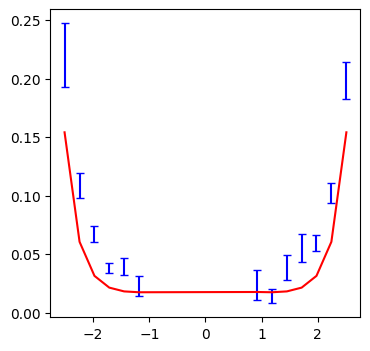

In [26]:
plotbin(51, th_harm)

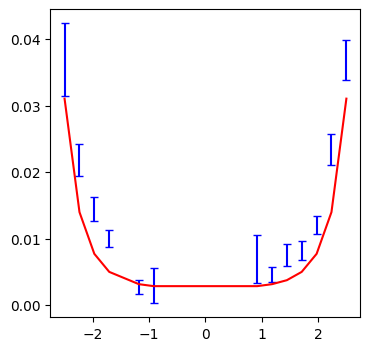

In [27]:
plotbin(97, th_harm)

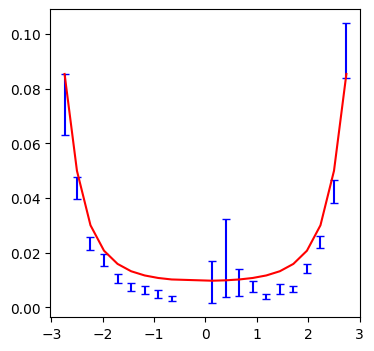

In [28]:
plotbin(146, th_harm)